In [762]:
%load_ext autoreload
%autoreload 2
import sisl
import numpy as np
import matplotlib.pyplot as plt
from mytools.plots import thesis_fig
from scipy.spatial import cKDTree
from mytools.construct import all_armchair
from ase.visualize.plot import plot_atoms

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [763]:
BOND = 1.42
phi = np.pi/3
B = BOND*np.cos(phi/2)

N0 = 4
N1 = 7
N2 = 12

R = (0.1, BOND+1e-2)
T = (0.0, -2.7)

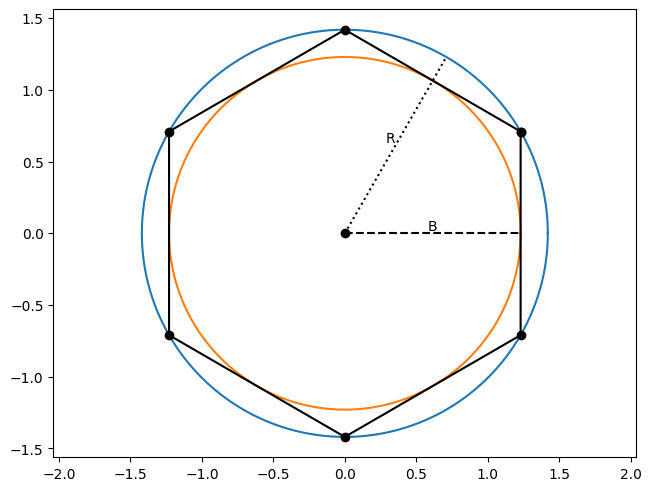

In [764]:
fig, ax = plt.subplots()
atoms = all_armchair(BOND)
atoms = atoms.translate(-atoms.center())
atoms = atoms.sub([3, 1, 0, 2, 4, 5, 3])
atoms = atoms.xyz[:, :2]
# print(atoms)
t = np.deg2rad(np.arange(0, 361, step=1))

outer_circ = np.array([np.cos(t)*BOND, np.sin(t)*BOND])
inner_circ = np.array([B*np.cos(t), B*np.sin(t)])
ax.plot(*outer_circ)
ax.plot(*inner_circ)
ax.plot(*atoms.T, color="k", linestyle="-", marker="o")
ax.plot([0, B], [0, 0], color="k", linestyle="--")
ax.scatter(0, 0, c="k", marker="o")
ax.text(B/2, 0, "B", verticalalignment="bottom", horizontalalignment="center")

ax.plot([0, BOND*np.cos(np.pi/3)], [0, BOND*np.sin(np.pi/3)], color="k", linestyle=":")
ax.text(BOND/2*np.cos(np.pi/3), BOND/2*np.sin(np.pi/3), "R", verticalalignment="bottom", horizontalalignment="right")

ax.axis("equal")
fig.set_constrained_layout(True)

In [765]:
def make_edge(geom, N0, N1):
    
    grev = geom.copy()
    grev.cell[0] = -geom.cell[0]
    grev.cell[1] = -geom.cell[1]
    grBottom = geom.tile(N0-1, 0)
    grRight = geom.tile(N1-1, 1).translate((N0-1)*geom.cell[0])
    grTop = grev.tile(N0-1, 0)\
        .translate((N1-1)*geom.cell[1])\
        .translate((N0-1)*geom.cell[0])
    grLeft = grev.tile(N1-1, 1).translate((N1-1)*geom.cell[1])
    grtot = grBottom + grRight + grTop + grLeft
    grtot.cell[0] = geom.cell[0]*N0
    grtot.cell[1] = geom.cell[1]*N1
    return grtot

In [766]:
graphene6 = all_armchair(BOND)

Ham0 = sisl.Hamiltonian(graphene6)
Ham0.construct([R, T])

total : 72,
 1 edge : 18,
 2 edge : 36,
 3 edge : 54,
 4 edge : 72


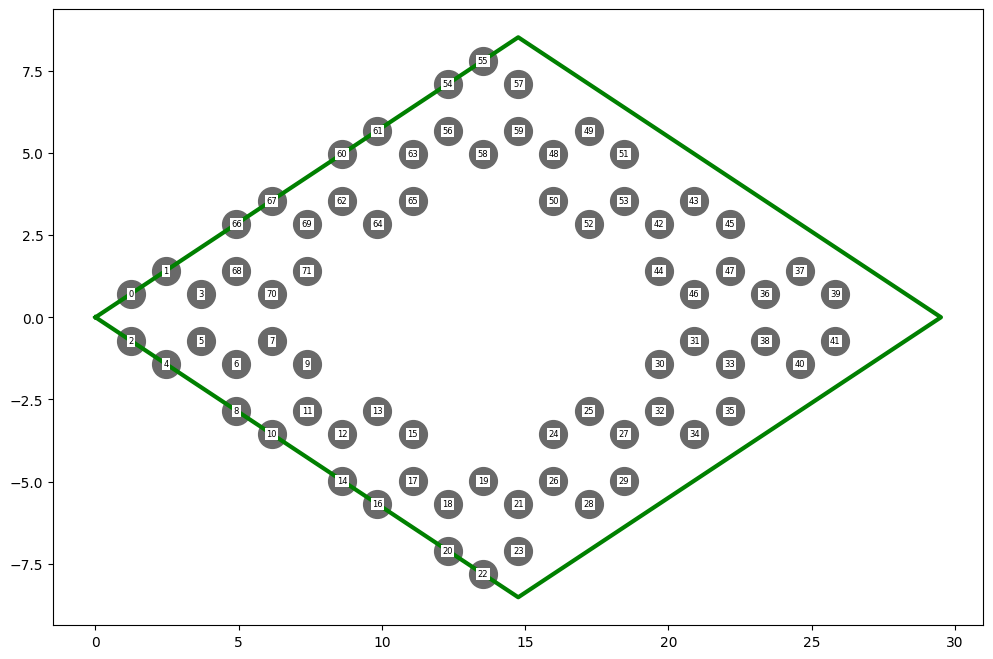

In [767]:
edge, corner_idx = make_edge(graphene6, N0, N0), None

print(f"total : {edge.na},\n 1 edge : {graphene6.na*(N0-1)},\n 2 edge : {graphene6.na*2*(N0 - 1)},\n 3 edge : {graphene6.na*3*(N0 -1)},\n 4 edge : {graphene6.na*4*(N0-1)}")

fig, ax = plt.subplots(figsize=(12,8))

# plot unit cell
A, B = edge.cell[:2, :2]
UC = np.array([0*A, A, A+B, B, 0*A])
ax.plot(*UC.T, color="g", lw=3)

coords = edge.xyz[:, :2]
ax.scatter(*coords.T, color="dimgrey", s=400)
for i in range(edge.na):
    x,y = coords[i]
    ax.text(x,y, s=i, fontsize=6, 
            verticalalignment="center", horizontalalignment="center",
            bbox=dict(facecolor="white", pad=1, edgecolor="none"),
                )

In [768]:
def plot_with_numbers(geom, ax=None, radii=None):
    from matplotlib import patches
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
    plot_atoms(geom.to.ase(), ax=ax, radii=radii)
    circles = ax.findobj(match=patches.Circle)
    xminp, yminp = np.min(np.array([c.center for c in circles]), axis=0)
    dx = xminp - min(edge.xyz[:, 0])
    
    x,y = geom.xyz[:, :2].T
    xmin, ymin = min(x), min(y)
    dx, dy = xminp - xmin, yminp - ymin
    
    for i in range(geom.na):
        ax.text(x[i] + dx , y[i] + dy, str(i), fontsize=8,
                ha="center", va="center",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.1)
                )
    
    ax.set_aspect("equal")


In [769]:
rsse1 = sisl.RealSpaceSE(Ham0, 0, 1, (N1, N1, 1))
rsse2 = sisl.RealSpaceSE(Ham0, 0, 1, (N2, N2, 1))

In [770]:
Ham_rs_elec1, elec_idx1 = rsse1.real_space_coupling(ret_indices=True)
Ham_rs_elec2, elec_idx2 = rsse2.real_space_coupling(ret_indices=True)

In [771]:
g1edge = make_edge(graphene6, N1, N1)
g1 = Ham0.geometry.tile(N1, 0).tile(N1, 1)
g2edge = make_edge(graphene6, N2, N2)
g2 = Ham0.geometry.tile(N2, 0).tile(N2, 1)

g1rsse = g1.sub(elec_idx1)
g2rsse = g2.sub(elec_idx2)

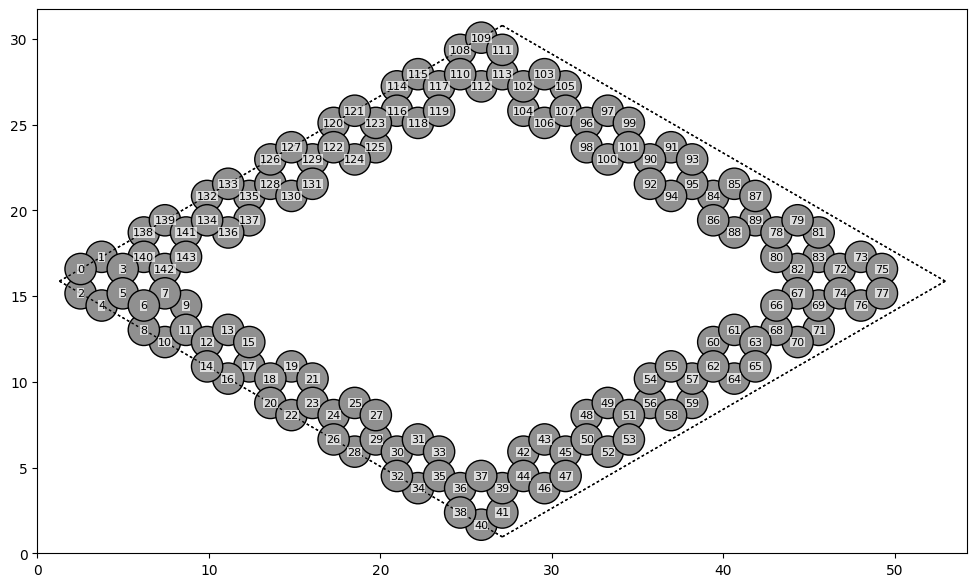

In [772]:
fig, ax = plt.subplots(figsize=(12,10))
plot_with_numbers(g1edge, ax=ax, radii=1.2)

In [773]:
def _tile_indices(n1: int, n2: int) -> tuple[int, int, int, int]:
    return 2*(n1+n2)-4, n1-1, n1+n2-2, 2*n1+n2-3

def get_corners(tile1, tile2=None, na=6, NC=1):
    if NC < 0:
        raise ValueError("## NC must be > 0")
    if tile2 is None:
        tile2 = tile1
    BL, BR, TR, TL = _tile_indices(tile1, tile2)
    corners_atom_match = [
        range(0, na*(NC + 1)), # bottom left hex + 1*NC
        range(na*(BR - NC), na*(BR + NC + 1)), # bottom right hex + 2*NC
        range(na*(TR - NC), na*(TR + NC + 1)), # top right hex + 2*NC
        range(na*(TL - NC), na*(TL + NC + 1)), # top left hex + 2*NC
        range(na*(BL - NC), na*BL) # bottom left 1*NC
    ]
    return np.concat(corners_atom_match)

def map_corners(tiles1, tiles2, na=6, NC=1):
    if not isinstance(tiles1, (tuple, list)):
        N1a, N1b = (tiles1, None)
    if not isinstance(tiles2, (tuple, list)):
        N2a, N2b = (tiles2, None)
    corners_match1 = get_corners(N1a, N1b, na, NC=NC)
    corners_match2 = get_corners(N2a, N2b, na, NC=NC)
    mapping = {}
    for i1, i2 in zip(corners_match1.flatten(), corners_match2.flatten()):
        mapping[int(i1)] = int(i2)
    return mapping

def get_edges(tile1, tile2, na=6, NC=1):
    if (NC < 0) or (2*NC > tile1-2) or (2*NC > tile2-2):
        raise ValueError("## NC must be > 0 and below (tile1-2)/2 and (tile2-2)/2")
    if tile2 is None:
        tile2 = tile1
    BL, BR, TR, TL = _tile_indices(tile1, tile2)
    corners_atom_match = [
        np.arange(na*(NC+1), na*(BR-NC)),
        np.arange(na*(BR+NC+1), na*(TR-NC)),
        np.arange(na*(TR+NC+1), na*(TL-NC)),
        np.arange(na*(TL+NC+1), na*(BL-NC)),
    ]
    return np.concat(corners_atom_match)

In [774]:
corn = get_corners(N2, N2, NC=1)

In [775]:
g2edge.plot(axes="xy",
            atoms_style=[
                dict(atoms=get_corners(N2, N2, NC=1), color="red"),
                dict(atoms=get_edges(N2, N2, NC=1), color="lime")
            ])

In [776]:
NC = 1
na = Ham0.na
corners1 = get_corners(N1, N1, na=na, NC=NC)
corners2 = get_corners(N2, N2, na=na, NC=NC)
edges1 = get_edges(N1, N1, na=na, NC=NC)
edges2 = get_edges(N2, N2, na=na, NC=NC)

In [777]:
def get_centers(coords, na):
    rolling_mean = []
    for i in range(0, len(coords), na):
        roll = coords[i:i+na].mean(axis=0)
        rolling_mean.append(roll)
    return np.array(rolling_mean)


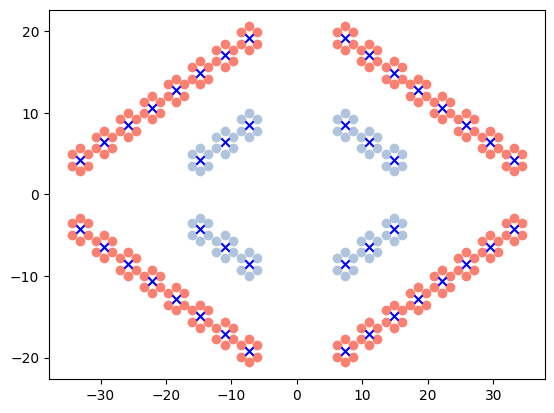

In [778]:
fig, ax = plt.subplots()

colors = ["lightsteelblue", "salmon"]
which = "edges"

for i, (geom, corn, ed) in enumerate(zip([g1edge.copy(), g2edge.copy()], 
                                         [corners1, corners2], 
                                         [edges1, edges2])):
    # geom = geom.copy()
    if which == "corners":
        xyz = geom.xyz[corn, :2]
    elif which == "edges":
        xyz = geom.xyz[ed, :2]
    elif which == "all":
        xyz = geom.xyz[:, :2]
    
    xyz -= geom.center()[:2]
    rolling_mean = get_centers(xyz, na=6)
    ax.scatter(*xyz[:, :2].T, color=colors[i])
    ax.scatter(*rolling_mean[:, :2].T, marker="x", color="blue")

In [779]:
cent1 = get_centers(g1edge.xyz[edges1], na=na)
cent2 = get_centers(g2edge.xyz[edges2], na=na)

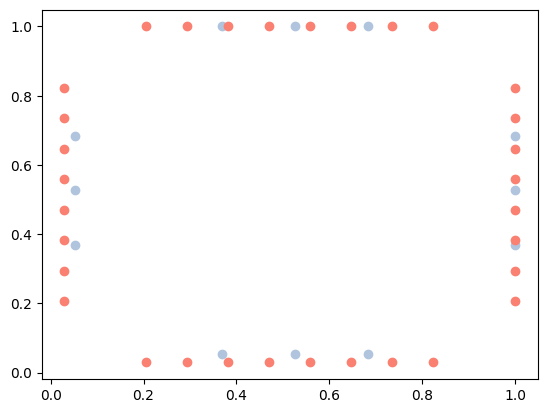

In [780]:
from mytools.scaling import get_fractional
coords = g1edge.copy().xyz[:, :2]
fig, ax = plt.subplots()
for i, (g, c) in enumerate(zip([g1edge, g2edge],
                             [cent1, cent2])):
    frac = get_fractional(g, c)
    ax.scatter(*frac.T, color=colors[i])

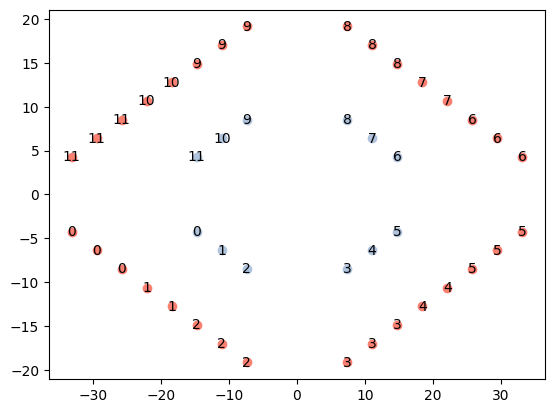

In [781]:
cent1_frac = get_fractional(g1edge, cent1)
cent2_frac = get_fractional(g2edge, cent2)
tree = cKDTree(cent1_frac)
dd, idx1_to_idx2 = tree.query(cent2_frac, k=1)

cent1_origo = cent1 - cent1.mean(axis=0)
cent2_origo = cent2 - cent2.mean(axis=0)

fig, ax = plt.subplots()
# plot atom centers for both
for i, c in enumerate([cent1_origo, cent2_origo]):
    ax.scatter(*c.T[:2], color=colors[i])

# plot 'center indicies' for geom 1
for i, (x,y,z) in enumerate(cent1_origo):
    ax.text(x,y, i, ha="center", va="center")

# plot 'center indicies' of geom 1 for geom 2
for i2, i1 in enumerate(idx1_to_idx2):
    x,y,_= cent2_origo[i2]
    ax.text(x, y, i1, ha="center", va="center")

In [782]:
tree = cKDTree(g2edge.xyz[:])
dd, center2_to_atoms2_idx = tree.query(cent2, k=na)
center2_to_atoms2_idx = np.sort(center2_to_atoms2_idx, axis=1)

In [783]:
tree = cKDTree(g1edge.xyz)
dd, center1_to_atoms1_idx = tree.query(cent1, k=na)
center1_to_atoms1_idx = np.sort(center1_to_atoms1_idx, axis=1)

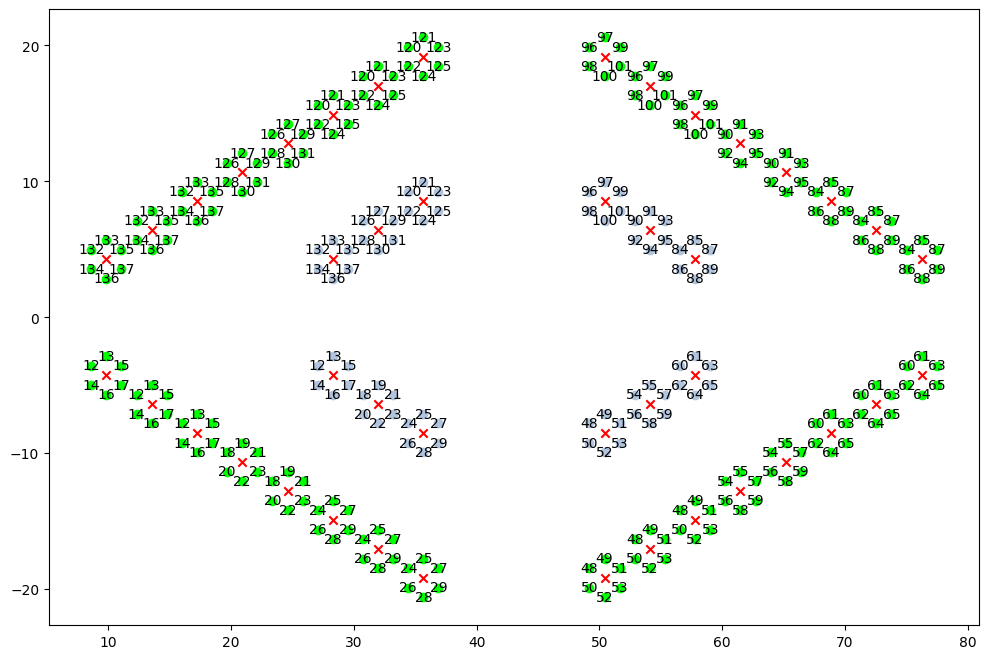

In [784]:

atoms = g2edge.xyz[edges2]
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(*atoms[:, :2].T, color="lime")
ax.scatter(*cent2[:, :2].T, color="r", marker="x")
for i2, i1 in enumerate(center1_to_atoms1_idx[idx1_to_idx2].flatten()):
    x_center, y_center, _ = atoms[i2]
    ax.text(x_center, y_center, i1, ha="center", va="center")


ax.scatter(*(g1edge.xyz[edges1, :2] - g1edge.center()[:2] + g2edge.center()[:2]).T, color="lightsteelblue")
ax.scatter(*(cent1- g1edge.center() + g2edge.center())[:, :2].T, color="r", marker="x")

for i, (x,y,_) in enumerate(g1edge.xyz[edges1] - g1edge.center() + g2edge.center()):
    ax.text(x, y, center1_to_atoms1_idx.flatten()[i], ha="center", va="center")

In [785]:
print("check :\n edges + corners = {}\n na = {}".format(corners1.shape[0] + edges1.shape[0], g1edge.na))

check :
 edges + corners = 144
 na = 144


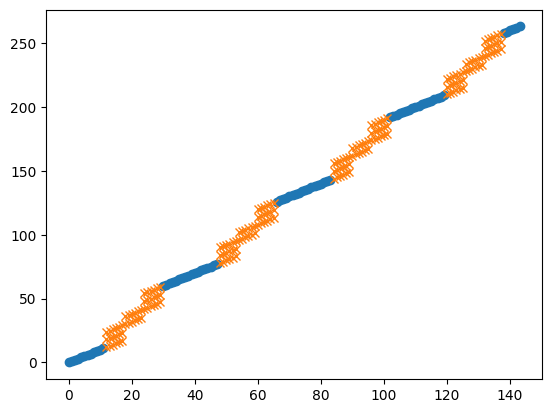

In [786]:
plt.plot(corners1, corners2, 'o'); 
plt.plot(edges1.reshape(-1, 6)[idx1_to_idx2].flatten(), edges2, 'x')

In [787]:
def _validate_nc(
    nc: int,
    n1: int = None,
    n2: int = None,
    *, 
    mode : str) -> None:
    if (nc < 0):
        raise ValueError(f"NC must be >= 0, got {nc}")
    if (mode == "edge") and (n1 is not None) and (n2 is not None):
        if (2 * nc > n1 -2) or (2 * nc > n2 -2):
            raise ValueError(
                f"NC = {nc} too large: must satisfy 2*nc <= min(n1-2, n2-2)="
                f"{min(n1-2, n2-2)}"
            )
    
    

In [788]:
def _tile_indices(n1: int, n2: int) -> tuple[int, int, int, int]:
    return 2*(n1+n2)-4, n1-1, n1+n2-2, 2*n1+n2-3

def get_corners(tile1, tile2=None, na=6, NC=1):
    if NC < 0:
        raise ValueError("## NC must be > 0")
    if tile2 is None:
        tile2 = tile1
    BL, BR, TR, TL = _tile_indices(tile1, tile2)
    corners_atom_match = [
        range(0, na*(NC + 1)), # bottom left hex + 1*NC
        range(na*(BR - NC), na*(BR + NC + 1)), # bottom right hex + 2*NC
        range(na*(TR - NC), na*(TR + NC + 1)), # top right hex + 2*NC
        range(na*(TL - NC), na*(TL + NC + 1)), # top left hex + 2*NC
        range(na*(BL - NC), na*BL) # bottom left 1*NC
    ]
    return np.concat(corners_atom_match)

def map_corners(tiles1, tiles2, na=6, NC=1):
    if not isinstance(tiles1, (tuple, list)):
        N1a, N1b = (tiles1, None)
    if not isinstance(tiles2, (tuple, list)):
        N2a, N2b = (tiles2, None)
    corners_match1 = get_corners(N1a, N1b, na, NC=NC)
    corners_match2 = get_corners(N2a, N2b, na, NC=NC)
    mapping = {}
    for i1, i2 in zip(corners_match1.flatten(), corners_match2.flatten()):
        mapping[int(i1)] = int(i2)
    return mapping

def get_edges(tile1, tile2, na=6, NC=1):
    if (NC < 0) or (2*NC > tile1-2) or (2*NC > tile2-2):
        raise ValueError("## NC must be > 0 and below (tile1-2)/2 and (tile2-2)/2")
    if tile2 is None:
        tile2 = tile1
    BL, BR, TR, TL = _tile_indices(tile1, tile2)
    corners_atom_match = [
        range(na*(1+NC), na*(BR-NC)),
        range(na*(BR+NC+1), na*(TR-NC)),
        range(na*(TR+NC+1), na*(TL-NC)),
        range(na*(TL+NC+1), na*(BL-NC)),
    ]
    return np.concat(corners_atom_match)

def get_centers(coords, na):
    rolling_mean = []
    for i in range(0, len(coords), na):
        roll = coords[i:i+na].mean(axis=0)
        rolling_mean.append(roll)
    return np.array(rolling_mean)

In [789]:
corners1 = get_corners(N1, N1, na=na, NC=NC)
corners2 = get_corners(N2, N2, na=na, NC=NC)
edges1 = get_edges(N1, N1, na=na, NC=NC)
edges2 = get_edges(N2, N2, na=na, NC=NC)

cent1 = get_centers(g1edge.xyz[edges1], na=na)
cent2 = get_centers(g2edge.xyz[edges2], na=na)

cent1_frac = get_fractional(g1edge, cent1)
cent2_frac = get_fractional(g2edge, cent2)
tree = cKDTree(cent1_frac)
dd, idx1_to_idx2 = tree.query(cent2_frac, k=1)

tree = cKDTree(g2edge.xyz[:])
dd, center2_to_atoms2_idx = tree.query(cent2, k=na)
center2_to_atoms2_idx = np.sort(center2_to_atoms2_idx, axis=1)

tree = cKDTree(g1edge.xyz)
dd, center1_to_atoms1_idx = tree.query(cent1, k=na)
center1_to_atoms1_idx = np.sort(center1_to_atoms1_idx, axis=1)

In [790]:
(
    center1_to_atoms1_idx[idx1_to_idx2] == edges1.reshape(-1, 6)[idx1_to_idx2]
).all()


np.True_

In [791]:
def map_edges(g1, g2, tiles1, tiles2, na=6, NC=1):
    if isinstance(tiles1, (tuple, list)):
        N1a, N1b = tiles1
    else:
        N1a = N1b = tiles1
    
    if isinstance(tiles2, (tuple, list)):
        N2a, N2b = tiles2
    else:
        N2a = N2b = tiles2
    
    # get centroids
    cent1 = get_centers(g1, na)
    cent2 = get_centers(g2, na)
    
    # get fractional centroids
    cent1_frac = get_fractional(g1, cent1)
    cent2_frac = get_fractional(g2, cent2)
    
    tree = cKDTree(cent1_frac)
    _, idx1_to_idx2 = tree.query(cent2_frac, k=1)
    
    tree = cKDTree(g1.xyz)
    _, centroids_to_atoms_idx1 = tree.query(cent1, k=na)
    centroids_to_atoms_idx1 = np.sort(centroids_to_atoms_idx1, axis=1)
    
    return centroids_to_atoms_idx1, idx1_to_idx2

def _splitter(arr, diff_tol):
    diff = np.diff(arr)
    print(np.abs(diff))
    split_idx = np.where(np.abs(diff) >= diff_tol)[0] + 1
    parts = np.split(arr, split_idx)
    return parts

def extrapolate(g1, g2, tiles1, tiles2, na=6, NC=1):
    if isinstance(tiles1, (tuple, list)):
        N1a, N1b = tiles1
    else:
        N1a = N1b = tiles1
        
    centroids_to_atoms_idx1, idx1_to_idx2 = map_edges(g1, g2, tiles1, tiles2, na, NC)
        
    # get corners and edges
    corners1 = get_corners(N1a, N1b, na, NC)
    edges1 = get_edges(N1a, N1b, na, NC).reshape(-1, na)
    print(edges1)
    # find edge sections using np.split
    edge_parts = _splitter(edges1[idx1_to_idx2].flatten(), na)
    # edge_parts = np.split(centroids_to_atoms_idx1[idx1_to_idx2].flatten(), splits)
    # print(centroids_to_atoms_idx1[idx1_to_idx2])
    # print(edges1)
    
    # find corner sections using np.split
    # diff = np.diff(corners1)
    # splits = np.where(np.abs(diff) >= na)[0] + 1
    
    corner_parts = _splitter(corners1, na)
    for part1, part2 in zip(corner_parts, edge_parts):
        # print(f"{len(part1)}   :   {part1}")
        # print(f"{len(part2)}   :   {part2}")
        pass
    
    # append to final list
    g1_to_g2_idx = np.concat([
            corner_parts[0],
            edge_parts[0],
            corner_parts[1],
            edge_parts[1],
            corner_parts[2],
            edge_parts[2],
            corner_parts[3],
            edge_parts[3],
            corner_parts[4],
        ])
    return g1_to_g2_idx

[[ 12  13  14  15  16  17]
 [ 18  19  20  21  22  23]
 [ 24  25  26  27  28  29]
 [ 48  49  50  51  52  53]
 [ 54  55  56  57  58  59]
 [ 60  61  62  63  64  65]
 [ 84  85  86  87  88  89]
 [ 90  91  92  93  94  95]
 [ 96  97  98  99 100 101]
 [120 121 122 123 124 125]
 [126 127 128 129 130 131]
 [132 133 134 135 136 137]]


IndexError: index 12 is out of bounds for axis 0 with size 12

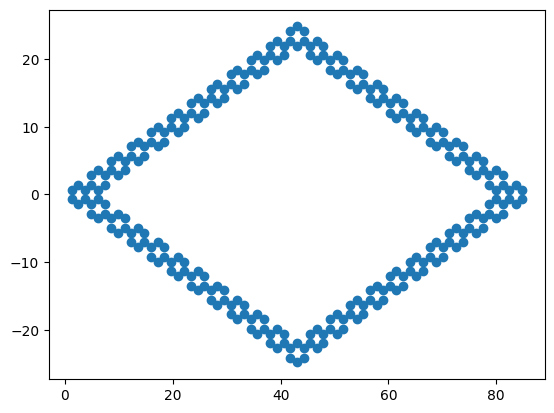

In [792]:
fig, ax = plt.subplots()

ax.scatter(*g2edge.xyz.T[:2])
g1_to_g2 = extrapolate(g1edge, g2edge, N1, N2, Ham0.na, NC=1)
# print(g1_to_g2)
for i2, i1 in enumerate(g1_to_g2):
    x,y,_ = g2edge.xyz[i2]
    ax.text(x,y,i1)